<div style="text-align: center; margin-top: 30px; margin-bottom: 30px;">

  <h1 style="display: inline-block; ">
    Handwritten Digit Recognition using Random Forest and AdaBoost
  </h1>

  <p style="max-width: 850px; margin: 15px auto 0 auto; font-size: 16px; line-height: 1.6;">
    This project explores handwritten digit classification using two ensemble machine learning algorithms:
    Random Forest and AdaBoost. The study includes data exploration, model training, performance evaluation,
    and a comparison of both algorithms for recognizing handwritten digits.
  </p>

</div>

------

<h1 style="display: inline-block; ">
  About Me</h1>

## Wessam Abo Zayed

**Automation Engineering · PLC Programming · Data Analyst** <br>

* Computer Scientist with a focus on Automation Engineering, PLC Programming, and Data Analytics. I combine technical expertise with analytical problem-solving skills to develop practical and efficient solutions for industrial automation systems and data-driven applications.

---

## Kontakt

<div style="text-align: left;">

<table style="margin-left: 0; margin-right: auto;">
  <tr>
    <th style="text-align: center;">Plattform</th>
    <th style="text-align: center;">Link</th>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>E-Mail</strong></td>
    <td style="text-align: left;">
      <a href="mailto:abozayed.wessam@gmail.com">abozayed.wessam@gmail.com</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>LinkedIn</strong></td>
    <td style="text-align: left;">
      <a href="https://www.linkedin.com/in/wessam-abozayed/">linkedin.com/in/wessam-abozayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>GitHub</strong></td>
    <td style="text-align: left;">
      <a href="https://github.com/wessam-abo-zayed">github.com/wessam-abo-zayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>Tableau Public</strong></td>
    <td style="text-align: left;">
      <a href="https://public.tableau.com/app/profile/wessam3726">public.tableau.com/app/profile/wessam3726</a>
    </td>
  </tr>
</table>

</div>


-------

<h1>Content</h1>

<ol>
    <li><a href="#libraries">Libraries</a></li>
    <li><a href="#exploring-data">Exploring Data</a></li>
    <li><a href="#random-forest">Random Forest</a></li>
    <li><a href="#adaboost">AdaBoost</a></li>
    <li><a href="#references">References</a></li>
</ol>

<a id="libraries"></a>
* <h3  >Libraries</h3>
<ol>
<li><h4>numpy:</h4>  which is a Python library to add support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays</li>
<li><h4>Padas:</h4>   which is  a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python.</li>
<li>matplotlib which is  a comprehensive library for creating static, animated, and interactive visualizations in Python.</li>
<li><h4>Sklearn:</h4> which is  a free machine learning library for Python</li>
from sklearn.model_selection we import 
<ul>
<li><h4>RandomizedSearchCV:</h4>  to tune hyperparameters  for ML model </li>
</ul>    
from sklearn.linear_model we import 
<ul>
<li><h4>metrics:</h4> to measure model preformance ,we used two metrics accuracy and confusion matrix  </li>
</ul>
<ul>
<li><h4>matplotlib:</h4> A lirary which help in visualiazation.  </li>
</ul>  
<ol>

- let's start by importing the required library 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics


- here is the MNIST dataset  after downloading it from <a>https://www.kaggle.com/oddrationale/mnist-in-csv</a>

<a id="exploring-data"></a>
### - Exploring Data:

In [3]:
train=pd.read_csv('mnist_train.csv/mnist_train.csv')
test=pd.read_csv('mnist_test.csv/mnist_test.csv')

In [5]:
print("number of training samples:",train.shape[0])
print("number of test samples:",test.shape[0])
print("number of columns:",train.shape[1])

number of training samples: 60000
number of test samples: 10000
number of columns: 785


- the dataset contain 600000 training sample and 10000 testing sample , it has 785 column , one of them which is the label column is our  traget variable that we want to predict and the 784 other columns is our features which stand for image pixels  

In [49]:
train.head(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- now we will create our features DF for training and testing  by removing label column 

In [83]:
train_data=train.loc[:,train.columns!="label"]
test_data=test.loc[:,test.columns!="label"]

In [84]:
label=train.label
test_label=test.label

- we can visualise a sample using matlpot library

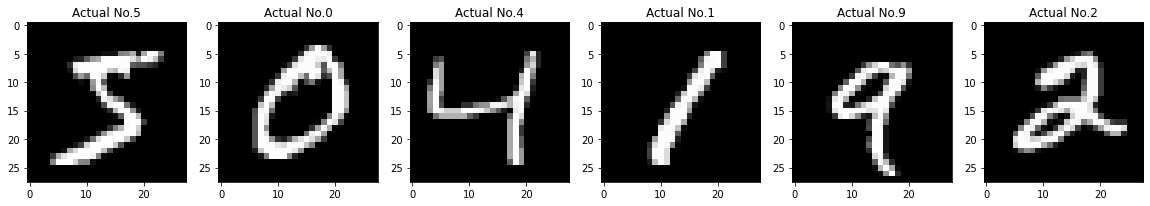

In [80]:
plt.figure(figsize=(20,5))
for index, (image,label) in enumerate(zip(train_data[:6].values, label[:6])):
    plt.subplot(1, 6, index+1)
    plt.imshow(np.reshape(image, (28,28)), cmap="gray")
    plt.title("Actual No.%s" % label)

<a id="random-forest"></a>
<h1>Random Forest:</h1>

- Random Forest is an  ensemble method , in which we combine multiple machine learning algorithms to obtain better predictive performance.

- the basic building block of a random forest is decision tree so first we will get some intution about the way it works then dive into random forest 

- <h3> Decision Tree:</h3>
<p>
A decision tree is a Machine Learning algorithm capable of fitting complex datasets and performing both classification and regression tasks. 
<p> The idea behind a tree is to search for a pair of variable-value within the training set and split it in such a way that will generate the "best" two child subsets. The goal is to create branches and leafs based on an optimal splitting criteria, a process called tree growing. 
 <p>   Specifically, at every branch or node, a conditional statement classifies the data point based on a fixed threshold in a specific variable, therefore splitting the data.
     <p>To make predictions, every new instance starts in the root node (top of the tree) and moves along the branches until it reaches a leaf node where no further branching is possible. 

- <h3> How do Decision Trees work?</h3>
<p>Decision trees use multiple algorithms to decide to split a node into two or more sub-nodes
as it   splits the nodes on all available variables and then selects the split which result in most homogeneous sub-nodes.
this task is performed recursively until the maximum depth of the tree is reached or an optimal tree is found. 
<p> Depending on the task, the algorithm may use a different metric  to measure the quality of the split like   Gini index or the Entropy for categorical decision trees, or the Residual or Mean Squared Error for regression trees. 
 <p> someo of the  algorithms used in Decision Trees is ID3, CART,CHAID and MARS  </p>
 let's an example of the some of the metrics 

* <h3>Gini Index</h3>
is a cost function used to evaluate splits in the dataset. It is calculated by subtracting the sum of the squared probabilities of each class from one
<img src="images/GINI_index_equation.png">
Higher value of Gini index implies higher inequality, higher heterogeneity,CART (Classification and Regression Tree) uses the Gini index method to create split points.

- <h3>problems with descision tree: </h3>
<ul>
<li>
    Trees have a high risk of overfitting the training data </li><li> can be  computationally complex if they are not constrained and regularized properly during the growing stage</li></ol>

- Therefore, in order to deal with this problem, we use Ensemble Learning, an approach that allows us to correct this overlearning habit and hopefully, arrive at better, stronger results.
<p>by  ensemble learning algorithm i mean  aggregating multiple outputs made by a diverse set of predictors to obtain better results. Formally, based on a set of “weak” learners we are trying to use a “strong” learner for our model. <p>
<p> by this we go back to Random forest </p>    

- <h3>Random Forest (strong learner) :</h3> (strong learner) is built as an ensemble of Decision Trees (weak learners) to perform different tasks such as regression and classification.

- <p> Random Forests are trained via the bagging method. Bagging or Bootstrap Aggregating, consists of randomly sampling subsets of the training data, fitting a model to these smaller data sets, and aggregating the predictions. This method allows several instances to be used repeatedly for the training stage given that we are sampling with replacement.<?p>
<p> The Random Forest  also  apply the bagging method to the feature space.thus adding more diversity and reducing the variance of the trees at the cost of equal or higher bias.  </p>

* <h3> how random forest make a prediction: </h3>
 it visits all the different trees in the ensemble, which  were grown using random samples of both training data and features. 
 <p>Depending on the task at hand, the functions used for aggregation will differ.
    <p>For Classification problems, it uses the mode or most frequent class predicted by the individual trees (also known as a majority vote), whereas for Regression tasks, it uses the average prediction of each tree.

* <h3>PROS:</h3>
<ul>
<li>Lower risk of overfitting. </li>
<li>Works well with non-linear data  </li>
<li>Robust to outliers. </li>
</ul>

* <h3>CONS:</h3>
<ul>
<li>the Random Forest algorithm is slow, as it has to grow many trees during training stage cause  it  is a greedy process. </li>
<li>Parameter Complexity </li>
<li>Random Forest is uesd for  regression but with  many regression models  in data science world, random forests may not be the go-to regression approach in every application.
It will not be able to predict any value outside the available values since averaging is a big part of random forest models. </li>
</ul>

* <h3> Random Forest parameters:</h3>
<ul>
    <li> The max_depth : the longest path between the root node and the leaf node as the max depth increase the tree start to overfit </li>
    <li>min_sample_split: a parameter that tells the decision tree in a random forest the minimum required number of observations in any given node in order to split it.  as increasing the min_sample_split the model start to underfit </li>
    <li>max_terminal_nodes :This hyperparameter sets a condition on the splitting of the nodes in the tree and hence restricts the growth of the tree as less terminal nodes specifiend the model is underfited </li>
    <li>min_samples_leaf: it specifies the minimum number of samples that should be present in the leaf node after splitting a node.</li>
    <li>n_estimators : the number of tree as more tree mean more time complexity  </li>
    <li>max_samples :determines what fraction of the original dataset is given to any individual tree.</li>
    <li>max_features :this resembles the number of maximum features provided to each tree in a random forest.  </li>
    <li> min_impurity_decrease :A node will be split if this split induces a decrease of the impurity greater than or equal to this value. </li>
    <li>min_impurity_split: Threshold for early stopping in tree growth. A node will split if its impurity is above the threshold, otherwise it is a leaf. </li>
</ul>

- let's  start with our first algorithm Random Forest  by importing it  from sikit learn :

In [9]:
from sklearn.ensemble import RandomForestClassifier

- firstly we need to choose the best parameters for our model using random search 
- <p>we will explore the following prameters (n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,bootstrap )

In [12]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 500, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

In [16]:
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

- here we create an  instance from RandomizedSearchCV  with the first parameter being our RandomForest model the second is dictionery with the parametrs we want to tune , for number of folds we choose 5 and the scoring metrics is accuracy , we choose 50 iteration for every fold so the total number of fits is 250    

In [17]:
rf_random = RandomizedSearchCV(estimator = RandomForestClassifier(), param_distributions = random_grid, cv=5, scoring="accuracy",verbose=1,n_jobs=4, 
                             n_iter=50, random_state = 0)

In [18]:
rf_random.fit(train_data, label)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 37.5min
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed: 154.5min
[Parallel(n_jobs=4)]: Done 250 out of 250 | elapsed: 236.0min finished


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=50,
                   n_jobs=4,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500]},
                   random_state=0, scoring='accuracy', verbose=1)

In [19]:
rf_random.best_score_

0.9712833333333333

In [20]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30,
 'bootstrap': False}

- let's loop over the 50 iteration to see accuracy ranges 

In [21]:

print("Best: %f using %s" % (rf_random.best_score_, rf_random.best_params_))
means = rf_random.cv_results_['mean_test_score']
stds = rf_random.cv_results_['std_test_score']
params = rf_random.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.971283 using {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
0.963517 (0.002884) with: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
0.968650 (0.002606) with: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 90, 'bootstrap': True}
0.966417 (0.002738) with: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
0.969067 (0.002491) with: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'auto', 'max_depth': 20, 'bootstrap': False}
0.969867 (0.002423) with: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
0.965033 (0.002894) with: {'n_estimators': 100, 'min_samples_split': 

- random_search results show that the best accuracy is   with:

<p> 'n_estimators': 500,
<p> 'min_samples_split': 5,
<p>'min_samples_leaf': 1,
<p> 'max_features': 'sqrt',
<p> 'max_depth': 30,
<p> 'bootstrap': False
 
    

- <p> Now let's fit the model with the entire 
training data   on the chosen parameters and validate it  with the test data available </p>

In [14]:
rf_model=RandomForestClassifier(n_estimators=500,min_samples_split= 5,min_samples_leaf= 1,max_features= 'sqrt',
max_depth=30,bootstrap= False)

In [15]:
rf_model.fit(train_data,label)

RandomForestClassifier(bootstrap=False, max_depth=30, max_features='sqrt',
                       min_samples_split=5, n_estimators=500)

In [44]:
predictions = rf_model.predict(test_data)

In [45]:
rf_score=metrics.accuracy_score(test_label,predictions)
print(rf_score)

0.9735


- <h2> we achive a 97.35 %  </h2>


- let's see the confusion matrix :

In [18]:
confusion_matrix = metrics.confusion_matrix(test_label, predictions)

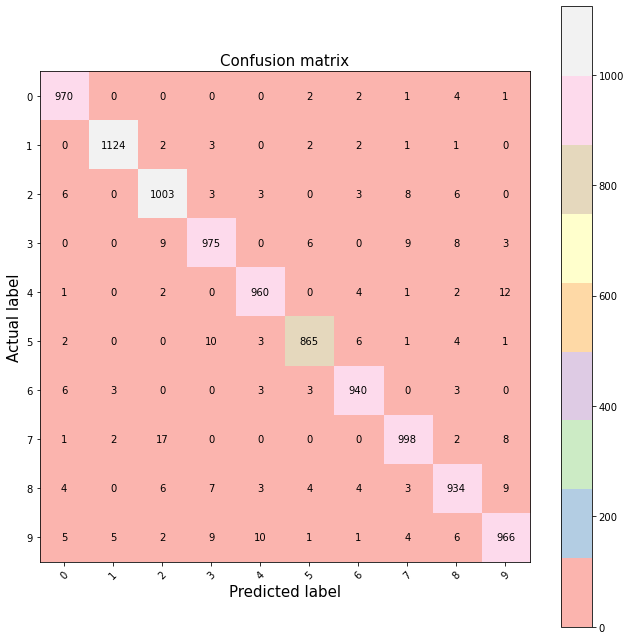

In [19]:
plt.figure(figsize=(9,9))
plt.imshow(confusion_matrix, interpolation='nearest', cmap='Pastel1')
plt.title('Confusion matrix', size = 15)
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], rotation=45, size = 10)
plt.yticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], size = 10)
plt.tight_layout()
plt.ylabel('Actual label', size = 15)
plt.xlabel('Predicted label', size = 15)
width, height = confusion_matrix.shape
for x in range(width):
 for y in range(height):
  plt.annotate(str(confusion_matrix[x][y]), xy=(y, x), 
  horizontalalignment='center',
  verticalalignment='center')

<a id="adaboost"></a>
- <h2> AdaBoost: </h2>
 AdaBoost algorithm, short for Adaptive Boosting, is a Boosting technique that is used as an Ensemble Method in Machine Learning. It is called Adaptive Boosting as the weights are re-assigned to each instance, with higher weights to incorrectly classified instances. It works on the principle where learners are grown sequentially. Except for the first, each subsequent learner is grown from previously grown learners. 

- <h3> How AdaBoost Works? </h3>
<ol>
<li>  Initially, Adaboost selects a training subset randomly </li>
<li> It iteratively trains the AdaBoost machine learning model by selecting the training set based on the accurate prediction of the last training. </li>
<li> It assigns the higher weight to wrong classified observations so that in the next iteration these observations will get the high probability for classification.</li>
<li>It assigns the weight to the trained classifier in each iteration according to the accuracy of the classifier. The more accurate classifier will get high weight.</li>
<li> This process iterate until it reach a specified minimum error rate or  until reached to the specified maximum number of estimators.</li>
</ol>

- in AdaBoost the base learner is called a stump which is a node with 2 leaves,  The stumps are weak learners, and boosting techniques prefer this

- in each iteration the best stump is selected by some measure like the Gini index or in this case is called wighted Gini index because every instance have diffrent weight 

- the istance weight is updated by the equation for incorrectly classified instance  :
- <p>New Sample Weight = Sample Weight * e^(Performance)    
- <p>Performance is the  preforamce of the previous classifier which is also  how much influence this stump will have in the final classification. 
<img src="images/stump_preformance.png">

- TE is The total error which is the total number of misclassified samples for sample weights.

- And for correctly classified records, we use the same formula with a negative sign with performance, so that the weight for correctly classified records will reduce compared to the incorrect classified ones as it will be incresed 

* the algorithm decide output for test 
* by weighted majority vote of the weak classifier (stump)  where each is assigned weight by the preformance of the stump 


-  <h3>AdaBoost Parameters:</h3>
AdaBoost don't have a lot of parameters to tune 
    <ol>
    <li>base_estimator: this for  the type of weak learner we want to use. It can Decision tree, Logistic Regressor, SVC anything as long as  it support for sample weighting .By default, the base estimator is a stump  DecisionTreeClassifier(max_depth=1).</li>
    <li> n_estimators: The number of base estimators. By default, the n_estimator is 50. </li>
    <li> learning_rate: This parameter is provided to shrink the contribution of each classifier. By default, it is provided a value of 1. </li>
    <li> algorithm: It can be either SAMME or SAMME.R.  SAMME.R uses the probability estimates to update the additive model, while SAMME uses the classifications only.  the SAMME.R algorithm typically converges faster than SAMME, achieving a lower test error with fewer boosting iterations. </li>
   </ol>

- <h3>PROS:</h3>
<ul>
<li> AdaBoost Algorithm is it is fast, simple and easy to program. </li>
<li> it has the flexibility to be combined with any machine learning algorithm </li>
<li> it is easier to use with less need for tweaking parameters  </li>
</ul>

- <h3>CONS:</h3>
<ul>
<li> AdaBoost is also extremely sensitive to Noisy data and outliers  </li>
<li> the method is almost impossible to scale up. This is because every estimator bases its correctness on the previous predictors, thus making the procedure difficult to streamline.</li>

</ul>

- <p> Now we will proceed with Adaboost.
- let's first import AdaBoost classifier from sikit learm :

In [22]:
from sklearn.ensemble import AdaBoostClassifier

- regarding adaboost we don't have a lot of parametrs to tune 
so i will explore the number of estimators beside the learning rate  

In [16]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 500, num = 10)]
learning_rate=[0.01,0.1,1,2]

In [17]:
random_grid = {'n_estimators': n_estimators,
               'learning_rate':learning_rate,
               }

- as RandomForest we will use RandomizedSearch to find the best parameters 


In [18]:
AdaBoost_random = RandomizedSearchCV(estimator = AdaBoostClassifier(), param_distributions = random_grid, cv=5, scoring="accuracy",verbose=1,n_jobs=4, 
                             n_iter=8, random_state = 0)

In [19]:
AdaBoost_random.fit(train_data, label)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  40 out of  40 | elapsed: 69.4min finished


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(), n_iter=8, n_jobs=4,
                   param_distributions={'learning_rate': [0.01, 0.1, 1, 2],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500]},
                   random_state=0, scoring='accuracy', verbose=1)

In [20]:

print("Best: %f using %s" % (AdaBoost_random.best_score_, AdaBoost_random.best_params_))
means = AdaBoost_random.cv_results_['mean_test_score']
stds = AdaBoost_random.cv_results_['std_test_score']
params = AdaBoost_random.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.806200 using {'n_estimators': 300, 'learning_rate': 0.1}
0.714767 (0.019181) with: {'n_estimators': 150, 'learning_rate': 1}
0.711967 (0.007431) with: {'n_estimators': 50, 'learning_rate': 1}
0.695783 (0.023060) with: {'n_estimators': 300, 'learning_rate': 1}
0.684917 (0.012589) with: {'n_estimators': 250, 'learning_rate': 0.01}
0.722650 (0.010171) with: {'n_estimators': 50, 'learning_rate': 0.1}
0.806200 (0.008577) with: {'n_estimators': 300, 'learning_rate': 0.1}
0.695150 (0.023088) with: {'n_estimators': 450, 'learning_rate': 1}
0.782050 (0.013829) with: {'n_estimators': 100, 'learning_rate': 0.1}


- the best accuracy is with 300 n_estimators and 0.1 learning rate 
<p> now let's fit our entire training set with the chosen parameters and see the model preforamnce using test data 

In [81]:
AdaBoostmodel=AdaBoostClassifier(n_estimators=300,learning_rate=0.1)

In [85]:
AdaBoostmodel.fit(train_data,label)

AdaBoostClassifier(learning_rate=0.1, n_estimators=300)

In [87]:
predictions = AdaBoostmodel.predict(test_data)

In [88]:
adaboost_score=metrics.accuracy_score(test_label,predictions)
print(adaboost_score)

0.8126


In [41]:
confusion_matrix = metrics.confusion_matrix(test_label, predictions)

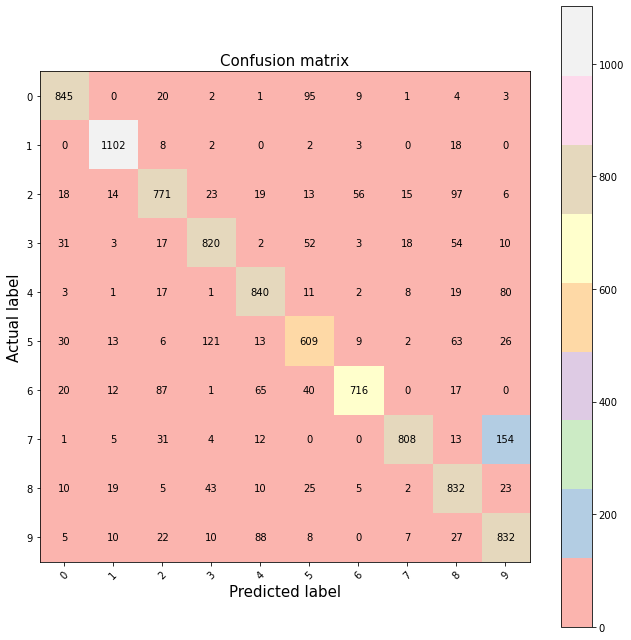

In [42]:
plt.figure(figsize=(9,9))
plt.imshow(confusion_matrix, interpolation='nearest', cmap='Pastel1')
plt.title('Confusion matrix', size = 15)
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], rotation=45, size = 10)
plt.yticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], size = 10)
plt.tight_layout()
plt.ylabel('Actual label', size = 15)
plt.xlabel('Predicted label', size = 15)
width, height = confusion_matrix.shape
for x in range(width):
 for y in range(height):
  plt.annotate(str(confusion_matrix[x][y]), xy=(y, x), 
  horizontalalignment='center',
  verticalalignment='center')

- comparing the preforamnce of the 2 models using bar plots 

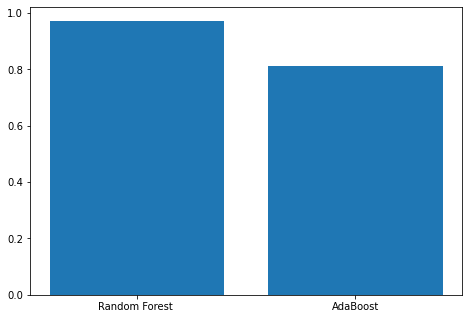

In [89]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
models = ['Random Forest ','AdaBoost']
accuracy = [rf_score,adaboost_score]
ax.bar(models,accuracy)
plt.show()

- we can see that random forest is better than Adaboost 
maybe because of the simple base_estimator used  in adaboost by default as it DecisionTreeClassifier(max_depth=1)
we can explore diffrent base estimator but due to the long time taken to tune hyperparameter using random search i didn't proceed

<a id="references"></a>
- <h3> References:</h3>
<ul>
    <li> <a> https://towardsdatascience.com/decision-trees-explained-3ec41632ceb6</a></li>
    <li><a>https://www.kdnuggets.com/2020/01/decision-tree-algorithm-explained.html</a></li>
    <li><a>https://www.kdnuggets.com/2017/10/random-forests-explained.html/</a></li>
    <li> <a> https://holypython.com/rf/random-forest-pros-cons/  </a></li>
    <li>  <a> https://www.analyticsvidhya.com/blog/2020/03/beginners-guide-random-forest-hyperparameter-tuning/</a></li>
    <li> <a> https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html </a></li>
    <li><a>https://www.datacamp.com/community/tutorials/adaboost-classifier-python</li>
    <li><a>https://blog.paperspace.com/adaboost-optimizer/</li>
    <li><a>https://www.mygreatlearning.com/blog/adaboost-algorithm/</li>
    <li><a>http://rob.schapire.net/papers/explaining-adaboost.pdf</li>
    <li><a>https://medium.com/@chaudhurysrijani/tuning-of-adaboost-with-computational-complexity-8727d01a9d20</li>
</ul>